# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Cut Nadya Putri Khairunnisa
- **Email:** cutnadyya@gmail.com  
- **ID Dicoding:** [CDCC001D6X2150]  

## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis berikut dibuat menggunakan konsep **SMART**: Specific, Measurable, Action-oriented, Relevant, dan Time-bound.

### Pertanyaan Bisnis

1. **Pada tahun 2017, state mana yang memiliki jumlah order tertinggi dan berapa kontribusinya terhadap total order, sehingga dapat dijadikan prioritas strategi pemasaran?**

2. **Pada tahun 2017, state mana yang memiliki rata-rata review score di bawah 4 dan bagaimana rata-rata payment value-nya, sehingga dapat diidentifikasi wilayah dengan kualitas layanan yang perlu diperbaiki?**

3. **Pada tahun 2017, state mana yang memiliki rasio customer terhadap seller paling tinggi, sehingga dapat menjadi prioritas ekspansi seller atau dukungan logistik?**

Analisis difokuskan pada tahun **2017** karena periode ini memiliki data transaksi yang lebih lengkap dibandingkan tahun awal dan dapat digunakan untuk melihat pola bisnis e-commerce secara lebih stabil.

## Import Semua Packages/Library yang Digunakan

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", None)

### Penjelasan Library
- `pandas` digunakan untuk membaca, membersihkan, dan mengolah data.
- `numpy` digunakan untuk operasi numerik.
- `matplotlib` dan `seaborn` digunakan untuk membuat visualisasi.
- `os` dan `pathlib` digunakan untuk membaca file dataset.

## Data Wrangling

### Gathering Data
Selanjutnya, seluruh dataset diimpor menggunakan library pandas.
Kode berikut disusun agar dapat dijalankan secara fleksibel, baik di Google Colab maupun pada lingkungan lokal. Jika menggunakan Google Colab, pastikan seluruh file CSV sudah diunggah terlebih dahulu ke direktori kerja Colab.

In [4]:
import pandas as pd
import os

dataset_path = ""

customers_df = pd.read_csv(os.path.join(dataset_path, 'customers_dataset.csv'))
geolocation_df = pd.read_csv(os.path.join(dataset_path, 'geolocation_dataset.csv'))
orders_df = pd.read_csv(os.path.join(dataset_path, 'orders_dataset.csv'))
order_items_df = pd.read_csv(os.path.join(dataset_path, 'order_items_dataset.csv'))
payments_df = pd.read_csv(os.path.join(dataset_path, 'order_payments_dataset.csv'))
products_df = pd.read_csv(os.path.join(dataset_path, 'products_dataset.csv'))
translation_df = pd.read_csv(os.path.join(dataset_path, 'product_category_name_translation.csv'))
reviews_df = pd.read_csv(os.path.join(dataset_path, 'order_reviews_dataset.csv'))
sellers_df = pd.read_csv(os.path.join(dataset_path, 'sellers_dataset.csv'))

dfs = {
    "customers": customers_df,
    "geolocation": geolocation_df,
    "orders": orders_df,
    "order_items": order_items_df,
    "payments": payments_df,
    "products": products_df,
    "translation": translation_df,
    "reviews": reviews_df,
    "sellers": sellers_df
}

for name, df in dfs.items():
    print(f"===== {name.upper()} =====")
    print("Shape:", df.shape)
    display(df.head())

===== CUSTOMERS =====
Shape: (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


===== GEOLOCATION =====
Shape: (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


===== ORDERS =====
Shape: (99441, 8)


...

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


===== REVIEWS =====
Shape: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


===== SELLERS =====
Shape: (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Insight Gathering Data
- Dataset mencakup sejumlah tabel penting, antara lain data pelanggan, pesanan, pembayaran, ulasan, produk, serta penjual.
- Setiap tabel saling terhubung melalui atribut tertentu seperti customer_id, order_id, dan seller_id.
- Data ini dapat dimanfaatkan untuk melakukan analisis performa bisnis berdasarkan daerah maupun provinsi tertentu.

### Assessing Data

Tahap berikutnya berfokus pada pengecekan kualitas data untuk memastikan dataset berada dalam kondisi yang baik sebelum dianalisis lebih lanjut. Proses ini mencakup identifikasi data yang hilang (missing value), pemeriksaan adanya data duplikat, pengecekan kesesuaian tipe data pada setiap kolom, serta peninjauan nilai unik pada beberapa atribut yang dianggap penting.

In [5]:
for name, df in dfs.items():
    print(f"\n===== {name.upper()} =====")
    print("Info:")
    print(df.info())
    print("\nMissing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))
    print("\nDuplicate rows:", df.duplicated().sum())

print("\nJumlah unique customer_state:", customers_df["customer_state"].nunique())
print("Jumlah unique seller_state:", sellers_df["seller_state"].nunique())
print("Review score unik:", sorted(reviews_df["review_score"].dropna().unique()))
print("Order status unik:", orders_df["order_status"].dropna().unique())
print("Payment type unik:", payments_df["payment_type"].dropna().unique())


===== CUSTOMERS =====
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Missing values:
Series([], dtype: int64)

Duplicate rows: 0

===== GEOLOCATION =====
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-

### Insight Assessing Data
Hasil pemeriksaan menunjukkan bahwa beberapa dataset masih memiliki nilai kosong, khususnya pada atribut terkait waktu pengiriman serta kategori produk. Selain itu, sejumlah kolom bertipe tanggal perlu dikonversi terlebih dahulu ke format datetime agar dapat digunakan dalam analisis berbasis waktu. Ditemukan pula beberapa baris data yang terduplikasi sehingga proses pembersihan data perlu dilakukan untuk menjaga kualitas dataset. Sementara itu, nilai review score berada pada skala 1 hingga 5, sehingga dapat digunakan sebagai indikator tingkat kepuasan pelanggan.

### Cleaning Data

Pada tahap ini dilakukan:
1. Membuat salinan dataset untuk menjaga agar data asli tidak berubah selama proses pengolahan.
2.Membersihkan data dengan menghapus baris yang terduplikasi.
3. Mengonversi kolom bertipe tanggal ke format datetime agar lebih mudah dianalisis.
4. Menangani missing value pada beberapa atribut penting yang digunakan dalam analisis.
5. Menambahkan fitur baru yang mendukung analisis transaksi pada tahun 2017.

In [6]:
#Membuat salinan dataset agar data asli tetap aman
customers_data = customers_df.copy()
geo_data = geolocation_df.copy()
orders_data = orders_df.copy()
items_data = order_items_df.copy()
payments_data = payments_df.copy()
products_data = products_df.copy()
translation_data = translation_df.copy()
reviews_data = reviews_df.copy()
sellers_data = sellers_df.copy()

# Membersihkan data duplikat pada setiap tabel
dataframes = [
    customers_data,
    geo_data,
    orders_data,
    items_data,
    payments_data,
    products_data,
    translation_data,
    reviews_data,
    sellers_data
]

for df in dataframes:
    df.drop_duplicates(inplace=True)

# Konversi atribut bertipe tanggal ke format datetime
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_date_columns:
    orders_data[column] = pd.to_datetime(orders_data[column], errors="coerce")

reviews_data["review_creation_date"] = pd.to_datetime(
    reviews_data["review_creation_date"], errors="coerce"
)

reviews_data["review_answer_timestamp"] = pd.to_datetime(
    reviews_data["review_answer_timestamp"], errors="coerce"
)

items_data["shipping_limit_date"] = pd.to_datetime(
    items_data["shipping_limit_date"], errors="coerce"
)

# Penanganan missing value pada atribut tertentu
products_data["product_category_name"] = (
    products_data["product_category_name"].fillna("unknown")
)

reviews_data = reviews_data[reviews_data["review_score"].notna()]
payments_data = payments_data[payments_data["payment_value"].notna()]
customers_data = customers_data[customers_data["customer_state"].notna()]
sellers_data = sellers_data[sellers_data["seller_state"].notna()]

# Menambahkan fitur berbasis waktu
orders_data["year_purchase"] = orders_data["order_purchase_timestamp"].dt.year
orders_data["month_purchase"] = orders_data["order_purchase_timestamp"].dt.month
orders_data["month_name_purchase"] = orders_data["order_purchase_timestamp"].dt.month_name()
orders_data["date_purchase"] = orders_data["order_purchase_timestamp"].dt.date

# Mengambil data transaksi pada tahun 2017
orders_2017 = orders_data.loc[
    orders_data["year_purchase"] == 2017
].copy()

print(
    "Total order pada tahun 2017:",
    orders_2017["order_id"].nunique()
)

print(
    "Periode transaksi tahun 2017:",
    orders_2017["order_purchase_timestamp"].min(),
    "hingga",
    orders_2017["order_purchase_timestamp"].max()
)

Total order pada tahun 2017: 45101
Periode transaksi tahun 2017: 2017-01-05 11:56:06 hingga 2017-12-31 23:29:31


In [8]:
for name, df in {
    "customers_clean": customers_data,
    "geolocation_clean": geo_data,
    "orders_clean": orders_data,
    "order_items_clean": items_data,
    "payments_clean": payments_data,
    "products_clean": products_data,
    "reviews_clean": reviews_data,
    "sellers_clean": sellers_data
}.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Total missing values:", df.isnull().sum().sum())
    print("Duplicate rows:", df.duplicated().sum())


customers_clean
Shape: (99441, 5)
Total missing values: 0
Duplicate rows: 0

geolocation_clean
Shape: (738332, 5)
Total missing values: 0
Duplicate rows: 0

orders_clean
Shape: (99441, 12)
Total missing values: 4908
Duplicate rows: 0

order_items_clean
Shape: (112650, 7)
Total missing values: 0
Duplicate rows: 0

payments_clean
Shape: (103886, 5)
Total missing values: 0
Duplicate rows: 0

products_clean
Shape: (32951, 9)
Total missing values: 1838
Duplicate rows: 0

reviews_clean
Shape: (99224, 7)
Total missing values: 145903
Duplicate rows: 0

sellers_clean
Shape: (3095, 4)
Total missing values: 0
Duplicate rows: 0


### Insight Cleaning Data
Proses pembersihan data telah berhasil dilakukan dengan menghapus seluruh data yang terduplikasi pada dataset. Selain itu, kolom yang berkaitan dengan tanggal sudah dikonversi ke format datetime sehingga lebih mudah digunakan dalam analisis berbasis waktu. Nilai kosong pada beberapa atribut penting juga telah ditangani agar kualitas data menjadi lebih baik. Selanjutnya, data transaksi tahun 2017 dipisahkan secara khusus untuk mendukung analisis yang berfokus pada aspek waktu (time-bound).


## Exploratory Data Analysis (EDA)

Pada tahap ini, data digabungkan menjadi satu dataframe utama untuk menjawab pertanyaan bisnis.

In [9]:
# Menghubungkan data transaksi dengan informasi pelanggan
customer_orders = orders_2017.merge(
    customers_data,
    on="customer_id",
    how="left"
)

# Menghitung total nominal pembayaran pada setiap pesanan
payment_summary = (
    payments_data
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

# Menghitung rata-rata skor ulasan tiap order
review_summary = (
    reviews_data
    .groupby("order_id", as_index=False)["review_score"]
    .mean()
)

# Menggabungkan seluruh data yang diperlukan ke dataset utama
combined_df = customer_orders.merge(
    payment_summary,
    on="order_id",
    how="left"
)

combined_df = combined_df.merge(
    review_summary,
    on="order_id",
    how="left"
)

display(combined_df.head())

print("Dimensi combined_df:", combined_df.shape)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_purchase,month_purchase,month_name_purchase,date_purchase,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,2017-10-02,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,4.0
1,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,2017-11-18,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,5.0
2,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,2017,7,July,2017-07-09,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,175.26,4.0
3,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,2017,4,April,2017-04-11,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,65.95,2.0
4,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,2017,5,May,2017-05-16,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,75.16,5.0


Dimensi combined_df: (45101, 18)


### EDA Pertanyaan 1  
**Pada tahun 2017, state mana yang memiliki jumlah order tertinggi dan berapa kontribusinya terhadap total order?**

In [10]:
# Menghitung jumlah transaksi berdasarkan state pelanggan
state_orders = (
    combined_df
    .groupby("customer_state")
    .agg(total_transactions=("order_id", "nunique"))
    .reset_index()
)

# Menghitung total keseluruhan order tahun 2017
overall_orders = state_orders["total_transactions"].sum()

# Menambahkan persentase kontribusi setiap state
state_orders["contribution_percentage"] = (
    state_orders["total_transactions"] / overall_orders * 100
)

# Mengurutkan data berdasarkan jumlah transaksi terbesar
state_orders = state_orders.sort_values(
    by="total_transactions",
    ascending=False
)

display(state_orders.head(10))

,customer_state,total_transactions,contribution_percentage
25,SP,17760,39.378284
18,RJ,6225,13.802355
10,MG,5414,12.004168
22,RS,2661,5.900091
17,PR,2270,5.033148
23,SC,1720,3.813663
4,BA,1592,3.529855
7,ES,968,2.146294
8,GO,955,2.117470
6,DF,921,2.042083


### EDA Pertanyaan 2  
**Pada tahun 2017, state mana yang memiliki rata-rata review score di bawah 4 dan bagaimana rata-rata payment value-nya?**

In [11]:
# Membuat ringkasan performa tiap state pelanggan
state_summary = (
    combined_df
    .groupby("customer_state")
    .agg(
        jumlah_order=("order_id", "nunique"),
        rata_review=("review_score", "mean"),
        rata_pembayaran=("payment_value", "mean")
    )
    .reset_index()
)

state_summary = state_summary.sort_values(
    by="rata_review",
    ascending=True
)

problematic_states = state_summary[
    (state_summary["rata_review"] < 4) &
    (state_summary["jumlah_order"] >= 100)
].copy()

display(problematic_states)

,customer_state,jumlah_order,rata_review,rata_pembayaran
9,MA,387,3.746753,197.598346
1,AL,207,3.765854,252.631256
24,SE,193,3.791667,211.574093
4,BA,1592,3.897966,178.595716
14,PB,260,3.929134,243.639615
18,RJ,6225,3.936309,169.631242
15,PE,772,3.942484,198.551671
13,PA,504,3.962151,218.657659
5,CE,660,3.972603,208.482045


### EDA Pertanyaan 3  
**Pada tahun 2017, state mana yang memiliki rasio customer terhadap seller paling tinggi?**

In [32]:
import numpy as np

customer_state_count = combined_df.groupby("customer_state").agg(
    total_customers=("customer_unique_id", "nunique")
).reset_index()

seller_state_count = sellers_data.groupby("seller_state").agg(
    total_sellers=("seller_id", "nunique")
).reset_index()

seller_state_count = seller_state_count.rename(columns={"seller_state": "customer_state"})

customer_seller_ratio = customer_state_count.merge(
    seller_state_count,
    on="customer_state",
    how="left"
)

customer_seller_ratio["total_sellers"] = customer_seller_ratio["total_sellers"].fillna(0)

customer_seller_ratio["customer_per_seller_ratio"] = np.where(
    customer_seller_ratio["total_sellers"] > 0,
    customer_seller_ratio["total_customers"] / customer_seller_ratio["total_sellers"],
    np.nan
)

customer_seller_ratio = customer_seller_ratio.sort_values(
    "customer_per_seller_ratio",
    ascending=False
)

display(customer_seller_ratio.head(10))

,customer_state,total_customers,total_sellers,customer_per_seller_ratio
13,PA,492,1.0,492.000000
9,MA,378,1.0,378.000000
16,PI,221,1.0,221.000000
12,MT,406,4.0,101.500000
24,SE,188,2.0,94.000000
15,PE,747,9.0,83.000000
4,BA,1546,19.0,81.368421
2,AM,72,1.0,72.000000
20,RO,133,2.0,66.500000
11,MS,287,5.0,57.400000


### Insight EDA
Analisis pada pertanyaan pertama dilakukan dengan melihat jumlah order serta persentase kontribusi transaksi pada masing-masing state. Selanjutnya, pertanyaan kedua dianalisis menggunakan rata-rata review score dan rata-rata payment value untuk setiap state guna memahami tingkat kepuasan pelanggan dan nilai transaksi. Sementara itu, pertanyaan ketiga dijawab melalui perbandingan rasio jumlah customer terhadap jumlah seller pada tiap wilayah. Seluruh proses analisis difokuskan pada data tahun 2017 agar tetap sesuai dengan aspek time-bound

## Visualization & Explanatory Analysis

### Pertanyaan 1  
**State dengan jumlah order tertinggi dan kontribusinya terhadap total order pada tahun 2017**

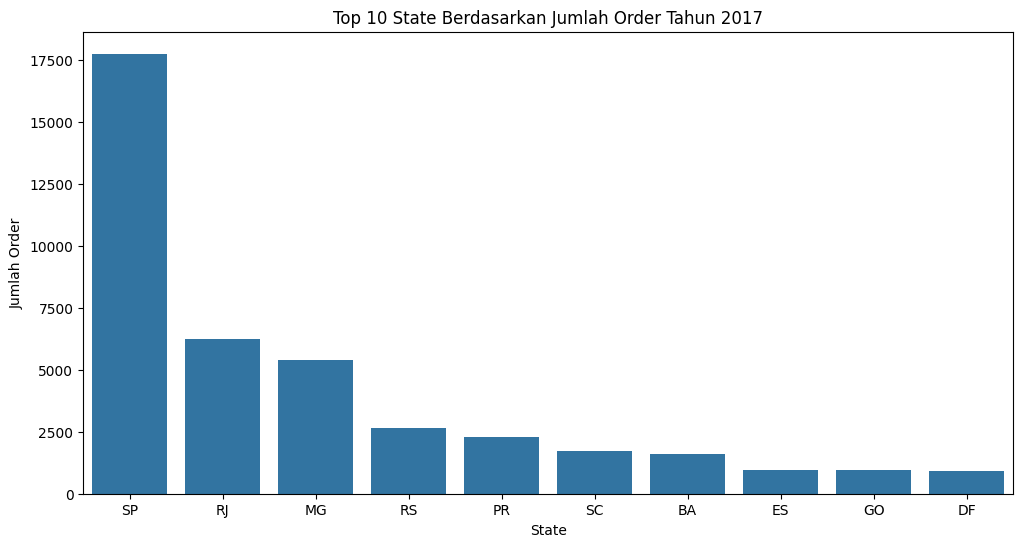

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

top_order_state = state_orders.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_order_state, x="customer_state", y="total_transactions")
plt.title("Top 10 State Berdasarkan Jumlah Order Tahun 2017")
plt.xlabel("State")
plt.ylabel("Jumlah Order")
plt.show()

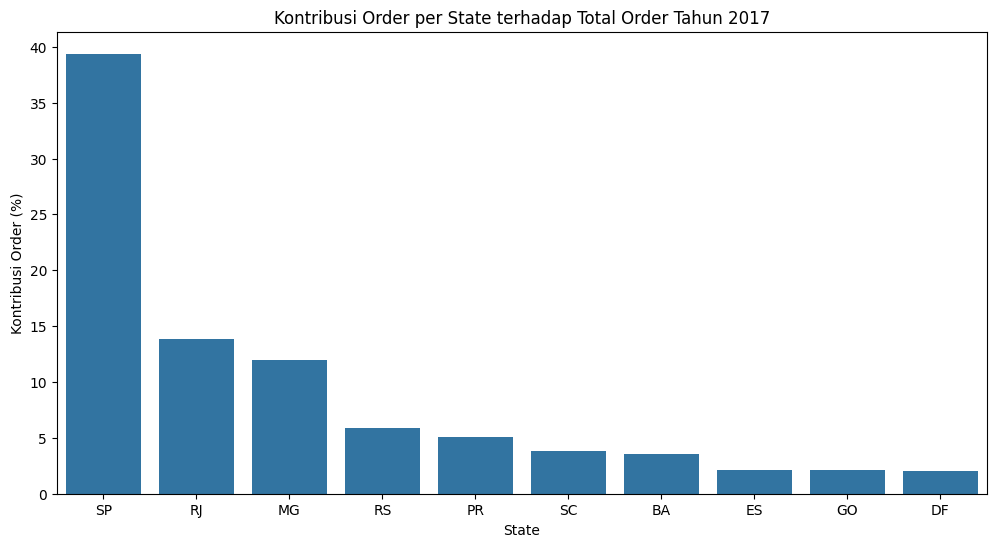

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_order_state, x="customer_state", y="contribution_percentage")
plt.title("Kontribusi Order per State terhadap Total Order Tahun 2017")
plt.xlabel("State")
plt.ylabel("Kontribusi Order (%)")
plt.show()

### Insight Pertanyaan 1
State dengan jumlah order tertinggi menunjukkan wilayah yang memiliki aktivitas transaksi paling besar selama tahun 2017. Besarnya persentase kontribusi order pada setiap state menggambarkan seberapa besar peran wilayah tersebut terhadap total transaksi keseluruhan. Oleh karena itu, state dengan kontribusi transaksi terbesar dapat dijadikan prioritas dalam strategi pemasaran karena memiliki basis pelanggan dan aktivitas pembelian yang paling kuat.

### Pertanyaan 2  
**State dengan rata-rata review score di bawah 4 dan rata-rata payment value pada tahun 2017**

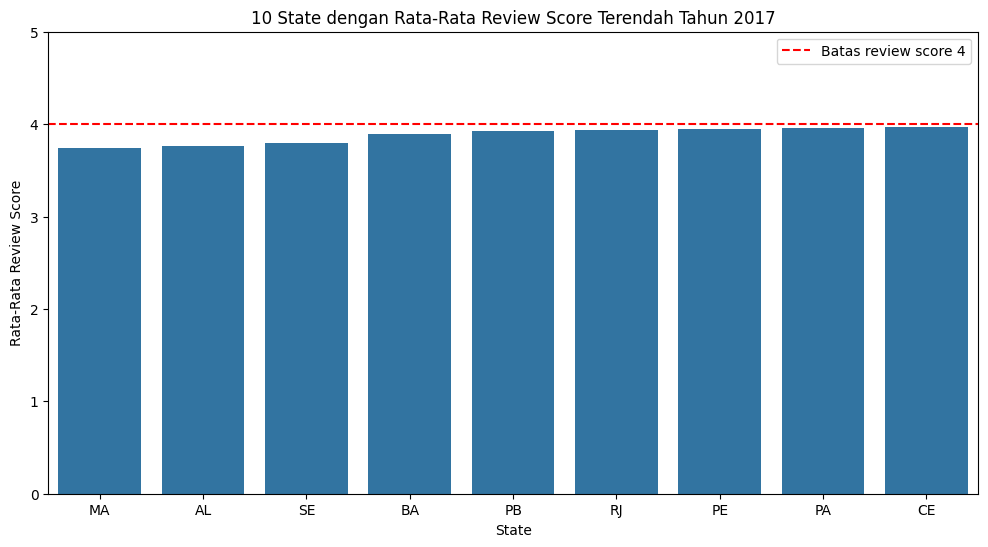

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=problematic_states.sort_values("rata_review").head(10),
    x="customer_state",
    y="rata_review"
)
plt.axhline(4, color="red", linestyle="--", label="Batas review score 4")
plt.title("10 State dengan Rata-Rata Review Score Terendah Tahun 2017")
plt.xlabel("State")
plt.ylabel("Rata-Rata Review Score")
plt.ylim(0, 5)
plt.legend()
plt.show()

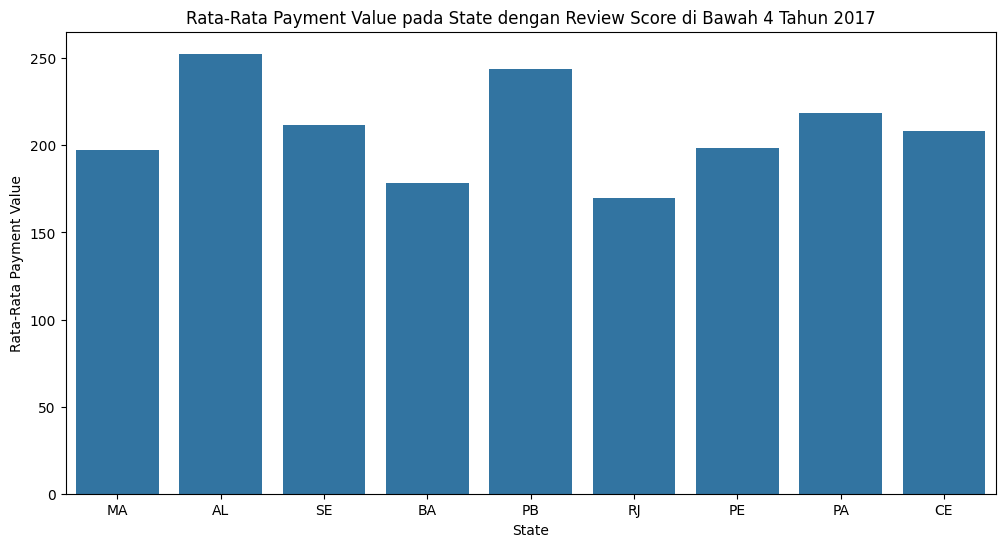

In [21]:
if len(problematic_states) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=problematic_states.sort_values("rata_review").head(10), x="customer_state", y="rata_pembayaran")
    plt.title("Rata-Rata Payment Value pada State dengan Review Score di Bawah 4 Tahun 2017")
    plt.xlabel("State")
    plt.ylabel("Rata-Rata Payment Value")
    plt.show()
else:
    print("Tidak ada state dengan total order >= 100 yang memiliki rata-rata review score di bawah 4.")

### Insight Pertanyaan 2
State dengan rata-rata review score di bawah 4 perlu menjadi perhatian karena menunjukkan tingkat kepuasan pelanggan yang masih relatif rendah. Apabila wilayah tersebut juga memiliki rata-rata payment value yang tinggi, maka peningkatan kualitas layanan menjadi semakin penting mengingat wilayah tersebut memiliki potensi nilai transaksi yang besar. Temuan ini dapat dimanfaatkan perusahaan untuk menentukan prioritas dalam melakukan evaluasi dan perbaikan kualitas layanan.

### Pertanyaan 3  
**Rasio customer terhadap seller per state pada tahun 2017**

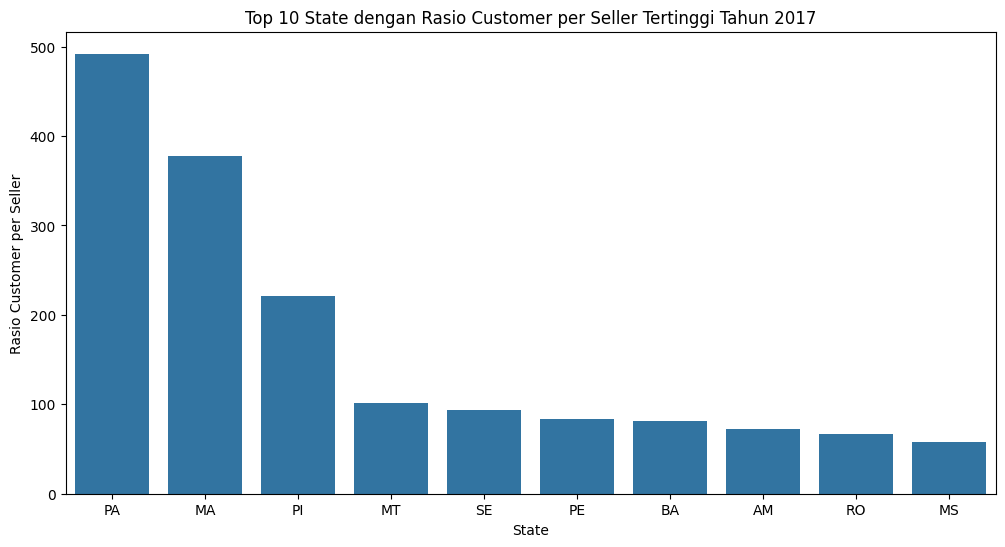

In [29]:
top_ratio_state = customer_seller_ratio.dropna().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_ratio_state,
    x="customer_state",
    y="customer_per_seller_ratio"
)
plt.title("Top 10 State dengan Rasio Customer per Seller Tertinggi Tahun 2017")
plt.xlabel("State")
plt.ylabel("Rasio Customer per Seller")
plt.show()

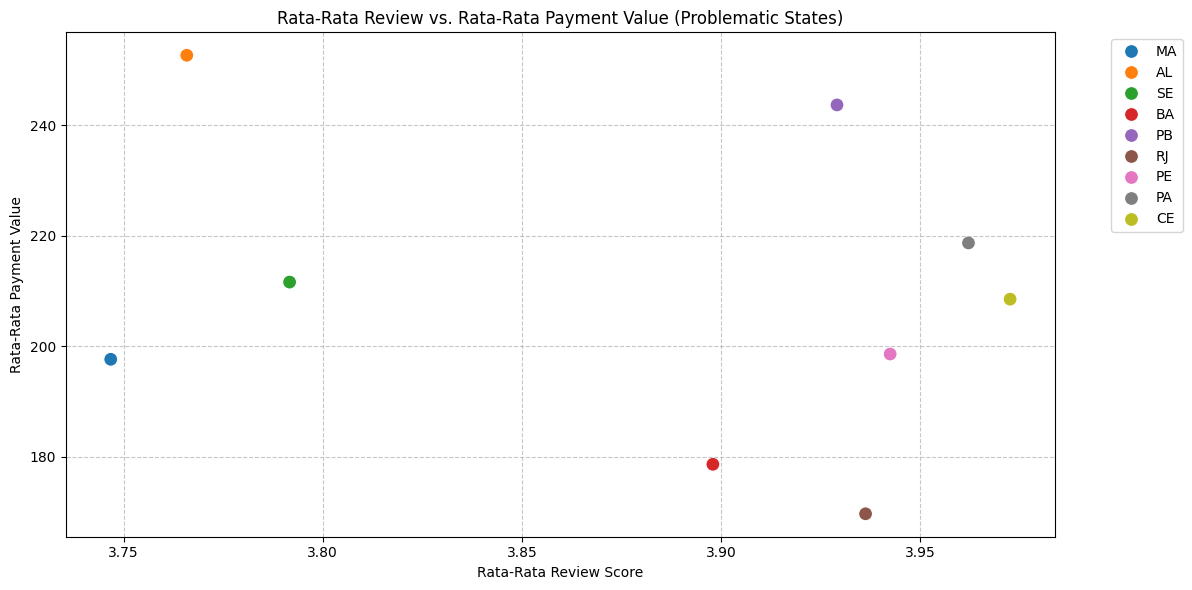

In [27]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=problematic_states,
    x="rata_review",
    y="rata_pembayaran",
    hue="customer_state", # Optional: to differentiate states by color
    s=100 # Optional: adjust marker size
)
plt.title("Rata-Rata Review vs. Rata-Rata Payment Value (Problematic States)")
plt.xlabel("Rata-Rata Review Score")
plt.ylabel("Rata-Rata Payment Value")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside if too many states
plt.tight_layout()
plt.show()

In [36]:
correlation = problematic_states['rata_review'].corr(problematic_states['rata_pembayaran'])
print(f"Pearson correlation coefficient between rata_review and rata_pembayaran: {correlation:.2f}")

Pearson correlation coefficient between rata_review and rata_pembayaran: -0.24


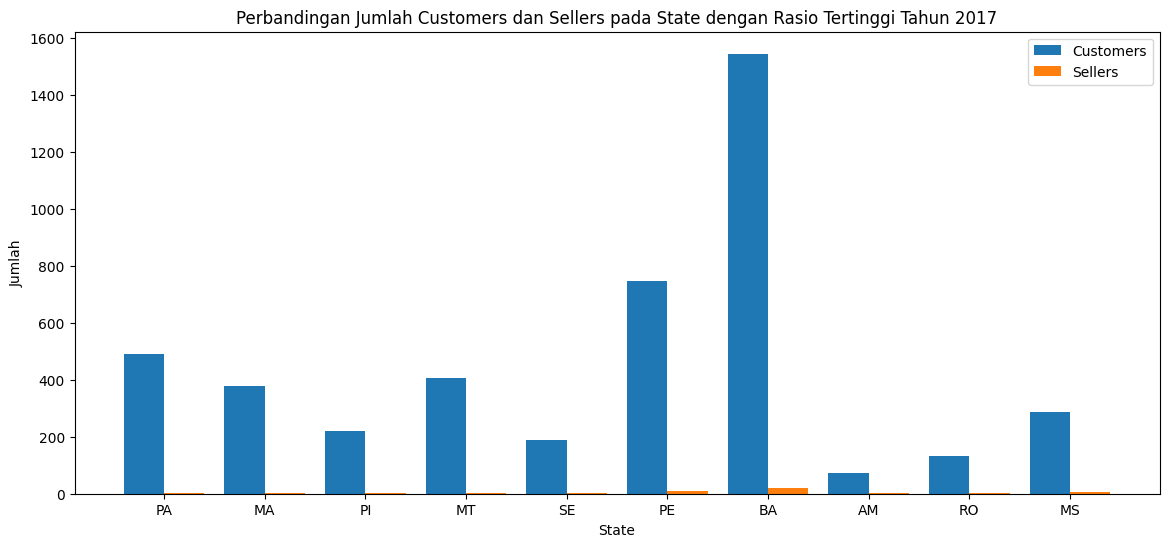

In [30]:
top_compare = customer_seller_ratio.dropna().head(10)

x = np.arange(len(top_compare))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, top_compare["total_customers"], width, label="Customers")
plt.bar(x + width/2, top_compare["total_sellers"], width, label="Sellers")

plt.xticks(x, top_compare["customer_state"])
plt.title("Perbandingan Jumlah Customers dan Sellers pada State dengan Rasio Tertinggi Tahun 2017")
plt.xlabel("State")
plt.ylabel("Jumlah")
plt.legend()
plt.show()

### Insight Pertanyaan 3
Rasio customer terhadap seller dapat digunakan untuk melihat keseimbangan antara tingkat permintaan (demand) dan ketersediaan penjual (supply) pada setiap state. State dengan rasio customer per seller yang tinggi menunjukkan bahwa jumlah pelanggan jauh lebih besar dibandingkan jumlah seller yang tersedia. Kondisi ini mengindikasikan adanya peluang pasar yang cukup besar sehingga wilayah tersebut berpotensi dijadikan prioritas untuk ekspansi seller, peningkatan layanan logistik, maupun pengembangan kerja sama dengan merchant lokal.

## Visualisasi Tambahan
Visualisasi tambahan berikut digunakan untuk memperkuat pemahaman terhadap data tahun 2017.

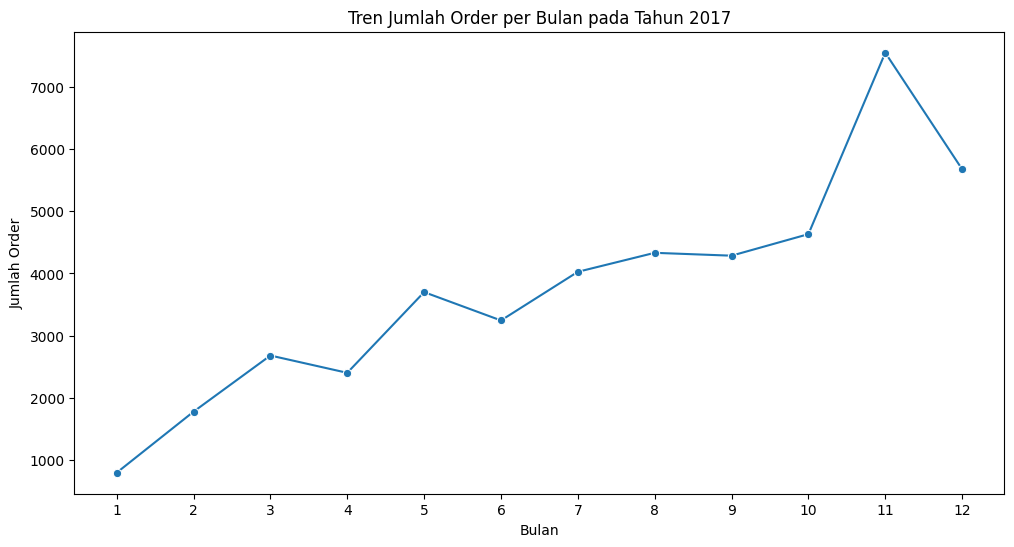

In [37]:
monthly_orders = orders_2017.groupby(["month_purchase"]).agg(
    total_order=("order_id", "nunique")
).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_orders, x="month_purchase", y="total_order", marker="o")
plt.title("Tren Jumlah Order per Bulan pada Tahun 2017")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.xticks(range(1, 13))
plt.show()

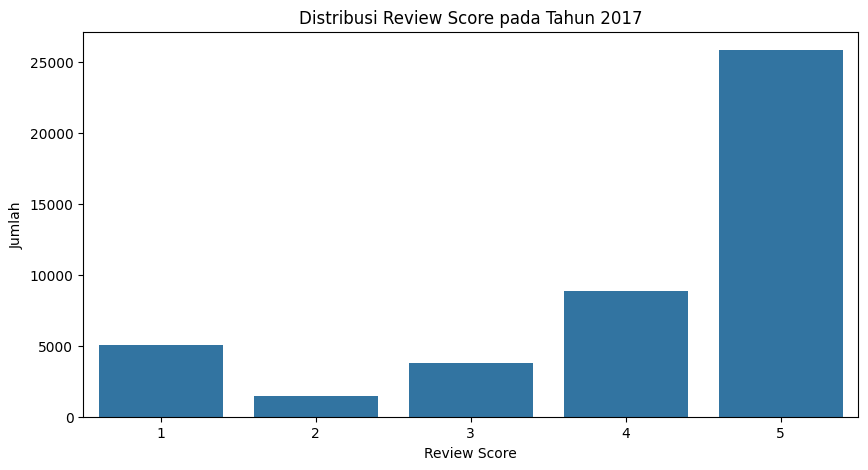

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(data=reviews_data.merge(orders_2017[["order_id"]], on="order_id", how="inner"), x="review_score")
plt.title("Distribusi Review Score pada Tahun 2017")
plt.xlabel("Review Score")
plt.ylabel("Jumlah")
plt.show()

### Rata-Rata Skor Ulasan pada Setiap Kategori Produk

In [40]:
product_review_scores = items_data.merge(
    reviews_data,
    on='order_id',
    how='left'
).merge(
    products_data,
    on='product_id',
    how='left'
).merge(
    translation_data,
    on='product_category_name',
    how='left'
)

# Calculate average review score per product category
avg_review_per_category = product_review_scores.groupby('product_category_name_english')\
                                                ['review_score'].mean().reset_index()

# Sort for better visualization
avg_review_per_category = avg_review_per_category.sort_values(by='review_score', ascending=False)

display(avg_review_per_category.head())

,product_category_name_english,review_score
11,cds_dvds_musicals,4.642857
29,fashion_childrens_clothes,4.500000
8,books_general_interest,4.446266
22,costruction_tools_tools,4.444444
35,flowers,4.419355


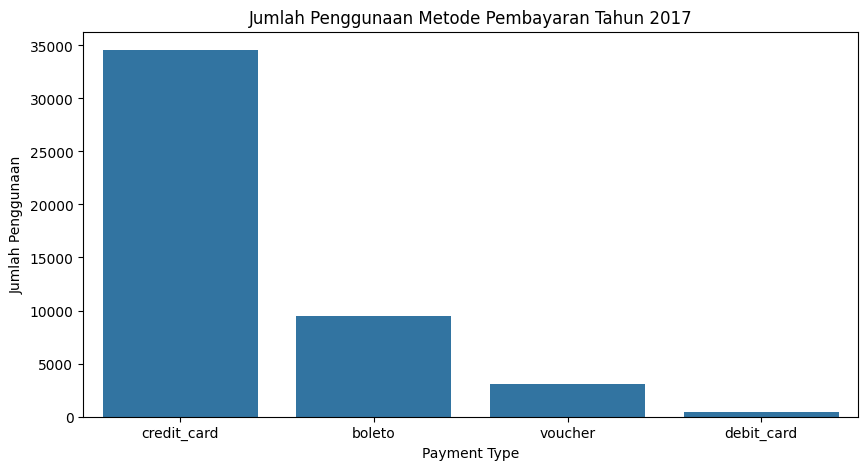

In [42]:
payments_2017 = payments_data.merge(
    orders_2017[["order_id"]],
    on="order_id",
    how="inner"
)

payment_type_count = payments_2017["payment_type"].value_counts().reset_index()
payment_type_count.columns = ["payment_type", "total_usage"]

plt.figure(figsize=(10, 5))
sns.barplot(data=payment_type_count, x="payment_type", y="total_usage")
plt.title("Jumlah Penggunaan Metode Pembayaran Tahun 2017")
plt.xlabel("Payment Type")
plt.ylabel("Jumlah Penggunaan")
plt.show()

## Conclusion & Recommendation

### Conclusion Pertanyaan 1
**Rekomendasi aksi:** Berdasarkan hasil analisis tahun 2017, beberapa state tercatat sebagai wilayah dengan jumlah dan kontribusi order paling dominan. Kondisi tersebut menunjukkan bahwa area tersebut memiliki aktivitas transaksi e-commerce yang sangat tinggi dan berpotensi menjadi pasar utama perusahaan.
Rekomendasi: perusahaan dapat mengarahkan strategi promosi, campaign pemasaran, serta alokasi anggaran marketing secara lebih optimal pada state dengan kontribusi order terbesar untuk meningkatkan peluang pertumbuhan penjualan.

### Conclusion Pertanyaan 2
**Rekomendasi aksi:** Hasil evaluasi pada tahun 2017 memperlihatkan adanya state dengan rata-rata review score di bawah 4, yang menandakan tingkat kepuasan pelanggan masih belum optimal. Apabila wilayah tersebut juga memiliki rata-rata payment value yang tinggi, maka peningkatan kualitas layanan perlu menjadi perhatian utama.
Rekomendasi: perusahaan sebaiknya melakukan perbaikan layanan pada wilayah dengan skor ulasan rendah, seperti meningkatkan kualitas pengiriman, menjaga ketersediaan produk, memperbaiki layanan pelanggan, serta mengoptimalkan proses transaksi.

### Conclusion Pertanyaan 3

**Rekomendasi aksi:** Dari analisis yang dilakukan pada tahun 2017, ditemukan beberapa state dengan rasio customer terhadap seller yang cukup tinggi. Hal ini menunjukkan bahwa jumlah permintaan pelanggan lebih besar dibandingkan ketersediaan seller di wilayah tersebut.
Rekomendasi: perusahaan dapat memprioritaskan penambahan seller baru, memperluas kerja sama dengan merchant lokal, serta meningkatkan dukungan distribusi dan logistik pada wilayah dengan rasio customer per seller tertinggi.

## Menyimpan Dataset Hasil Analisis

Dataset hasil penggabungan dan tabel analisis disimpan agar dapat digunakan untuk dashboard atau analisis lanjutan.

In [45]:
combined_df.to_csv("all_data_2017.csv", index=False)
state_orders.to_csv("order_by_state_2017.csv", index=False)
problematic_states.to_csv("state_performance_2017.csv", index=False)
customer_seller_ratio.to_csv("customer_seller_ratio_2017.csv", index=False)
monthly_orders.to_csv("monthly_orders_2017.csv", index=False)

print("File hasil analisis berhasil disimpan.")

File hasil analisis berhasil disimpan.
